# **A. Numpy**

## **1. Array**
- Chúng ta làm quen từ những kiến thức cơ bản nhất nhé, đó là `vector` và `matrix`.
  - `Vector` đơn giản là 1 `list` có 1 chiều.
  - `Matrix` là 1 `list` gồm những `vector`, tức là chứa nhiều `list` nhỏ đóng vai trò là 1 dòng.

![](https://i.imgur.com/AvCRHT2.png)

In [ ]:
vector = [0, 1, 2, 3]
matrix = [[1, 2, 3],
          [4, 5, 6]]

print(type(vector))
print(type(matrix))

<class 'list'>
<class 'list'>


- Với bản chất là `list` thì thao tác với `vector` và `matrix` đã được học ở môn `Programming 1` rồi!

### **TODO 1: Property of `vector` and `matrix` (Easy)**

- Hãy giúp Hỷ in ra kích thước của `vector a` và của `matrix b`.

In [ ]:
temp = [1]
vector_a = temp + temp
matrix_b = [vector_a, [1, 0]]

print(vector_a) # bao nhiêu elements?
print(matrix_b) # bao nhiêu dòng, cột?


# YOUR CODE GOES HERE
print(len(vector_a))
print(len(matrix_b))

[1, 1]
[[1, 1], [1, 0]]
2
2


- Thử nhân vô hướng `dot product` `vector a` và `matrix b` xem được không.

In [ ]:
# YOUR CODE GOES HERE
result = 0
for i in range(len(vector_a)):
  result += vector_a[i] * matrix_b[0][i]
print(result)


2


- Giúp Hỷ `transpose` `matrix b` với.

In [ ]:
# YOUR CODE GOES HERE
transpose = []

for j in range(len(matrix_b[0])):
    row = []
    for i in range(len(matrix_b)):
        row.append(matrix_b[i][j])
    transpose.append(row)

print(transpose)

[[1, 1], [1, 0]]


- Rõ ràng, `transpose` một ma trận với kiểu dữ liệu `list` khá phức tạp, trong khi đây lại là bước khá cơ bản của đại số tuyển tính.
- Từ đó người ta sinh ra kiểu dữ liệu gọi là `np.array` để tính toán với ma trận (vốn là core của AI) nhanh hơn.

In [ ]:
import numpy as np

a = np.array(vector_a)
b = np.array(matrix_b)
temp = np.array(temp) # ghi đè biến

print(a, type(a))
print(b, type(b))

[1 1] <class 'numpy.ndarray'>
[[1 1]
 [1 0]] <class 'numpy.ndarray'>


- Hãy thử in `shape` (kích thước) của `a` và `b` nhá
- Sau đó, in ra `transpose` của `a` và `b` luôn.

In [ ]:
# YOUR CODE GOES HERE
import numpy as np

a = np.array(vector_a)
b = np.array(matrix_b)

print(a.shape)
print(b.shape)
print(np.dot(a, b))
print(b.T)

(2,)
(2, 2)
[2 1]
[[1 1]
 [1 0]]


- Thử nhân vô hướng `dot product` và nhân có hướng `cross product` của `a` và `b` nào.

In [ ]:
dot_product1 = np.matmul(a, a) # vector . vector
dot_product2 = a @ b # vector . matrix
cross_product = np.cross(b, a)

print(dot_product1)
print(dot_product2)
print(cross_product)

2
[2 1]
[0 1]


/tmp/ipykernel_2119/1266151693.py:3: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  cross_product = np.cross(b, a)


### **TODO 2: Solve linear equation (Medium)**
- Dùng các kỹ thuật `slicing` trong `numpy` để giải phương trình sau bằng phương pháp `Gaussian`:

$$\begin{bmatrix}
2 & 3 \\
4 & -1
\end{bmatrix}
\begin{bmatrix}
x \\
y
\end{bmatrix}
=
\begin{bmatrix}
5 \\
3
\end{bmatrix}$$

In [ ]:
import numpy as  np
# YOUR CODE GOES HERE
A = np.array([[2, 3],
              [4, -1]])

B = np.array([5, 3])

factor = A[1, 0] / A[0, 0]
A[1, :] = A[1, :] - factor * A[0, :]
B[1] = B[1] - factor * B[0]
y = B[1] / A[1, 1]
x = (B[0] - A[0, 1] * y) / A[0, 0]

print(x, y)

1.0 1.0


### **TODO 3: Compute cosine similarity (Easy)**
- Tính `cosine similarity` từ `object1` và `object2`.

$$\text{similarity}(\mathbf{A}, \mathbf{B}) = \cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|}$$

In [ ]:
obj1 = np.array([3, 5])
obj2 = np.array([5, 4])

# YOUR CODE GOES HERE
dot = np.dot(obj1, obj2)
norm1 = np.linalg.norm(obj1)
norm2 = np.linalg.norm(obj2)

cosine = dot / (norm1 * norm2)

print(cosine)

0.9374252720097652


- Dễ quá nên là hãy thử 2 vector `object` trên vào hệ trục tọa độ nhé.

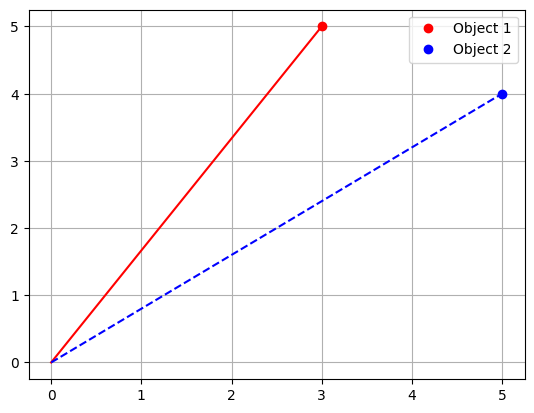

In [ ]:
import matplotlib.pyplot as plt

# Plot the points
plt.plot(obj1[0], obj1[1], 'ro', label='Object 1') # 'ro' = red circle
plt.plot(obj2[0], obj2[1], 'bo', label='Object 2') # 'bo' = blue circle

# Draw lines from origin (0,0) to the points
plt.plot([0, obj1[0]], [0, obj1[1]], 'r') # nét liền
plt.plot([0, obj2[0]], [0, obj2[1]], 'b--') # nét đứt

plt.grid(True)
plt.legend()
plt.show()

- Tính góc giữa 2 vector nhé.

In [ ]:
# YOUR CODE GOES HERE
angle = np.arccos(cosine)
print(angle)
print(np.degrees(angle))

0.3556358843007601
20.376435213836405


- Như được học thì `cosine similarity` giúp xác định độ giống nhau của 2 `vector/matrix`.

## **2. Numpy function**

### **TODO 4: `sum`, `mean`, `max`, `min` (Easy)**

- Demo các hàm kể trên nhá.

In [ ]:
import numpy as np

a = np.array([[0,1,2,3,4],
              [2,4,6,8,10],
              [3,5,7,9,11],
              [-1,0,-2,8,3]])

# np.sum(a)  # mean, min, max
# a.sum()
np.sum(a, axis=0)
# a.sum(axis=0)
np.mean(a, axis=1)
# a.sum(axis=1)

array([2. , 6. , 7. , 1.6])

Cho  ma trận $A$
- Tính tổng các giá trị nhỏ nhất trên từng hàng của ma trận $A$
- In ra số nhỏ nhất trong "các giá trị lớn nhất trên từng cột của ma trận $A^T$"

In [ ]:
import numpy as np

A = np.array([[-1, 3, 2, -2],
              [5, -4, 0, -2],
              [0, 7, 3, 1]])

# YOUR CODE GOES HERE
row_min = np.min(A, axis=1)
print(np.sum(row_min))

col_max_AT = np.max(A.T, axis=0)
print(np.min(col_max_AT))

-6
3


### **TODO 5: `argmin`, `argmax` (Easy)**

In [ ]:
# 1D array
import numpy as np

a = np.array([1, 0, 2, 0, 5, 5])

print(np.argmin(a), np.argmax(a))
# print(a.argmin(), a.argmax())

1 4


In [ ]:
# 2D array
import numpy as np

a = np.array([[1,  3, 2],
              [0, -1, 5]])

print(np.argmin(a, axis=0), np.argmax(a, axis=0))
# print(a.argmin(axis=0), a.argmax(axis=0))

[1 1 0] [0 0 1]


Cho danh sách tên học sinh & điểm trung bình mỗi học sinh lưu trong 2 list. In ra tên học sinh có điểm trung bình cao nhất/thấp nhất & số điểm của học sinh đó. Yêu cầu: dùng các hàm numpy, **không dùng vòng lặp**

In [ ]:
import numpy as np

names = ['Hà', 'Huy', 'Tâm', 'Mai', 'Long']
grades = [6.3, 7.7, 5.8, 6.8, 8.4]

max_idx = np.argmax(grades)
min_idx = np.argmin(grades)

print(names[max_idx], grades[max_idx])
print(names[min_idx], grades[min_idx])


Long 8.4
Tâm 5.8


### **concatenate**

Các array có thể `concatenate` với nhau khi shape phù hợp:
- Cùng số chiều
- Nếu concatenate theo chiều thứ `i` thì **`shape[i]` có thể khác nhau**, còn lại phải giống nhau

<center>
<img src="https://www.sharpsightlabs.com/wp-content/uploads/2018/12/numpy-concatenate_featured-image.png" height=300>
</center>

<center>
<img src="https://img-blog.csdnimg.cn/20191225141504649.png?x-oss-process=image/watermark,type_ZmFuZ3poZW5naGVpdGk,shadow_10,text_aHR0cHM6Ly9ibG9nLmNzZG4ubmV0L2xiajIzaGFvMQ==,size_16,color_FFFFFF,t_70">
</center>

In [ ]:
import numpy as np

# AXIS = 0

a = np.array([1, 2, 3])
b = np.array([4, 5])

a = np.array([[1,2,4],
              [5,6,8],
              [5,2,8]]) # 3x3
b = np.array([[0,1,2],
              [1,3,5]]) # 2x3

c = np.concatenate((a, b))
print(c, c.shape)

[[1 2 4]
 [5 6 8]
 [5 2 8]
 [0 1 2]
 [1 3 5]] (5, 3)


In [ ]:
# AXIS = 1

a = np.array([[1,2,4,3],    # 2x4
              [5,2,8,1]])
b = np.array([[0,1,2],      # 2x3
              [1,3,5]])

c = np.concatenate((a, b), axis = 1)

print(c, c.shape)

[[1 2 4 3 0 1 2]
 [5 2 8 1 1 3 5]] (2, 7)


### **where**

**Search**

In [ ]:
import numpy as np

# a = np.array([5, -4, 7, -8, 6, 9])
# a = np.array([[5, -4, 7],
#               [-8, 6, 9]])
# r = np.where(a < 6)
# print(r, type(r))
# print(a[r])
# print(a[np.where(a < 6)])

a = np.array([5, 4, 7, 8, 5, 9])
b = np.array([1, 4, 6, 3, 5, 7])
print(a[np.where(a > b)])

[5 7 8 9]


**Create New Array**

In [ ]:
# replace by condition

# new_array = np.where(old_array_condition, value_if_true, value_if_false)

In [ ]:
import numpy as np

a = np.array([5, -4, 7, -8, 6, 9])
b = np.where(a > 0, a**(.5), -a)
b, b.shape

/tmp/ipykernel_2119/444310369.py:4: RuntimeWarning: invalid value encountered in power
  b = np.where(a > 0, a**(.5), -a)


(array([2.23606798, 4.        , 2.64575131, 8.        , 2.44948974,
        3.        ]),
 (6,))

### **filter**

In [ ]:
filter = (a > 0) & (a % 2 == 0)
print(a[filter])


[6]


In [ ]:
# 1D array
import numpy as np

a = np.array([5, 4, 7, 8, 5, 9])
b = np.array([1, 4, 6, 3, 5, 7]) # Changed b to have 6 elements, like a
# print(a < 6)
# print(a[(a > 0) & (a % 2 == 0)])
# print(a[(a > 0) | (a % 2 == 0)])
print(a[~(a < 6)])
print(a[a == b])

[7 8 9]
[4 5]


In [ ]:
# 2D array
# TODO: lấy ra các dòng của ma trận a mà có số đầu tiên = 0 (tức là cột 0 = 0)
import numpy as np

a = np.array([[0, -1, 3],
              [1, 0, -1],
              [0, 2, 1],
              [-1, 1, 0]])
# a = np.array([[0, -1, 3], [1, 0, -1], [0, 2, -3], [-1, 1, 0]])
        #    [  a0      ,   a1      ,  a2       ,  a3]
# a[[True, False, True, False]]

# c0 = a[:,0]
# print(c0)
# print(c0 == 0)
# print(a[a[:,0] == 0])
print(a[(a[:,0] == 0) & (a[:, 2] == 1)])

[[0 2 1]]


### **TODO 6: `where`, `filter` (Easy)**

Cho danh sách nhân viên như sau:

Tên|Giới tính|Cấp bậc|Mức lương
-|-|-|-
An|Nam|Nhân viên|10000
Bình|Nữ|Quản lý|50000
Châu|Nữ|Nhân viên|30000
Dũng|Nam|Quản lý|60000

1. In ra danh sách các quản lý
2. In ra tên các nhân viên nam
3. In ra lương trung bình của các quản lý
4. Tạo mảng chứa tiền thưởng của mỗi người, với cấp nhân viên được thưởng 5000, quản lý được 10000
5. Thêm cột tiền thưởng vào danh sách nhân viên trên

In [ ]:
import numpy as np

nv = [['An',   'Nam', 'Nhân viên', 10000],
      ['Bình', 'Nữ',  'Quản lý',   50000],
      ['Châu', 'Nữ',  'Nhân viên', 30000],
      ['Dũng', 'Nam', 'Quản lý',   60000]]

# YOUR CODE HERE

import numpy as np

nv = np.array([
    ['An', 'Nam', 'Nhân viên', 10000],
    ['Bình', 'Nữ', 'Quản lý', 50000],
    ['Châu', 'Nữ', 'Nhân viên', 30000],
    ['Dũng', 'Nam', 'Quản lý', 60000]
], dtype=object)

mngs = nv[nv[:,2] == 'Quản lý']
print(mngs)

male_employees = nv[nv[:,1] == 'Nam']
print(male_employees)

mng_salary = nv[nv[:,2] == 'Quản lý'][:,3].astype(int)
print(np.mean(mng_salary))

reward = np.where(nv[:,2] == 'Nhân viên', 5000, 10000)
print(reward)

reward = reward.reshape(-1,1)
nv_new = np.concatenate((nv, reward), axis=1)

print(nv_new)

[['Bình' 'Nữ' 'Quản lý' 50000]
 ['Dũng' 'Nam' 'Quản lý' 60000]]
[['An' 'Nam' 'Nhân viên' 10000]
 ['Dũng' 'Nam' 'Quản lý' 60000]]
55000.0
[ 5000 10000  5000 10000]
[['An' 'Nam' 'Nhân viên' 10000 5000]
 ['Bình' 'Nữ' 'Quản lý' 50000 10000]
 ['Châu' 'Nữ' 'Nhân viên' 30000 5000]
 ['Dũng' 'Nam' 'Quản lý' 60000 10000]]


### **TODO 7: Clustering `kMeans` (Hard)**

- Ngoài dùng góc để đo độ giống nhau, người ta còn dùng khoảng cách nữa.
- Mục tiêu của thuật toán `K-Means` là tối thiểu hóa tổng bình phương khoảng cách từ các điểm đến tâm cụm của chúng (center):

$$J = \sum_{i=1}^{K} \sum_{x \in C_i} \|x - \mu_i\|^2$$

- Trong đó:
    - $K$: Số lượng cụm.
    - $C_i$: Tập hợp các điểm thuộc cụm thứ $i$.
    - $x$: Một điểm dữ liệu trong cụm.
    - $\mu_i$: Tọa độ tâm (mean) của cụm thứ $i$.
    - $\|x - \mu_i\|^2$: Bình phương khoảng cách Euclidean giữa điểm $x$ và tâm $\mu_i$.
    - $\mu_i$: Tâm của cụm, tính bằng cách trung bình cộng các tọa độ điểm lại.

- Giờ thử tạo random một số điểm để thử bài toán gom cụm `clustering` nhé.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# random các điểm
np.random.seed(42)
cluster1 = np.random.randn(20, 2) + np.array([2, 2])
cluster2 = np.random.randn(20, 2) + np.array([7, 7])
cluster3 = np.random.randn(20, 2) + np.array([2, 7])
X = np.vstack([cluster1, cluster2, cluster3])

- Thử vẽ đồ thị plot những điểm trong X vừa tạo nào.

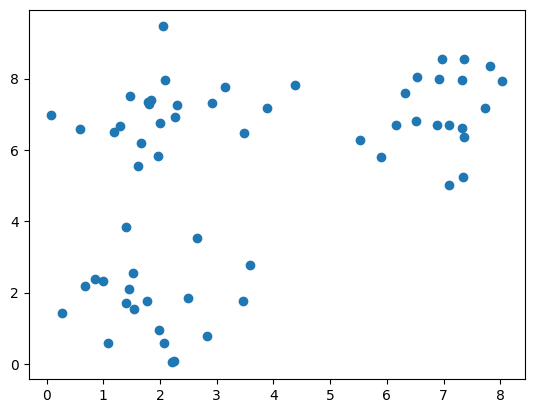

In [ ]:
import matplotlib.pyplot as plt

# YOUR CODE GOES HERE
plt.scatter(X[:, 0], X[:, 1])
plt.show()

- Flow để code chay được thuật toán `kMeans` như sau:
    - Khởi tạo ngẫu nhiên các điểm center tương ứng với số class cần gom cụm.
    - Tính khoảng cách giữa tất cả các điểm đến tất cả center.
    - Điểm gần center nào nhất thì sẽ được gán class đó.
    - Sau khi gom cụm lần đầu, tính lại center là trung bình cộng các điểm trong class.
    - Lặp đi lặp lại việc tính khoảng cách và center, ta đã thành công bài toán `classification` cấp độ cơ bản nhất.

Nhìn hàm khá đơn giản với chuyên Toán và Lý nhỉ. Thế giúp Hỷ viết lại thuật toán trên để gom những điểm Hỷ tạo sẵn thành 3 cụm nhé.

In [ ]:
# 1. Khởi tạo ngẫu nhiên các center
k = 3
cen1, cen2, cen3 = np.random.randn(3, 2)
centroid = np.array([cen1, cen2, cen3])
print(centroid)

# 2. Tính khoảng cách giữa all points tới all centroid
def distance(X, centroid): # Tên hàm là distance
    distances = []
    for i in range(len(X)):
        dis = np.linalg.norm(X[i] - centroid, axis=1)
        distances.append(dis)
    return np.array(distances)

# 3. Gán nhãn các điểm
def labeling(dis):
    label = np.argmin(dis, axis=1)
    return label

# 4. Tính lại centroid
def center(X, k, label, centroid):
    for i in range(k):
        points_in_cluster = X[label == i]
        if len(points_in_cluster) > 0:
            centroid[i] = np.mean(points_in_cluster, axis=0)
    return centroid

# 5. Lặp đi lặp lại bước đó 10 lần
for i in range(30):
    # Đổi tên biến kết quả để không ghi đè lên hàm distance
    dist_matrix = distance(X, centroid)
    label = labeling(dist_matrix)
    centroid = center(X, k, label, centroid)

print(centroid)

[[ 0.79103195 -0.90938745]
 [ 1.40279431 -1.40185106]
 [ 0.58685709  2.19045563]]
[[1.30074687 2.1624538 ]
 [2.60862219 1.10339262]
 [4.40049632 7.08063335]]


- Vẽ lại đồ thị trên nhưng với màu sắc là label của các điểm.

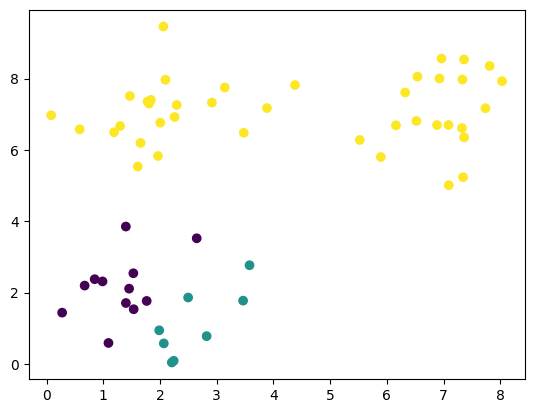

In [ ]:
import matplotlib.pyplot as plt

# YOUR CODE GOES HERE
plt.scatter(X[:, 0], X[:, 1], c=label)
plt.show()

### **TODO 8: Predict class `kNN` (Easy)**

- Nếu `kMeans` là bài toán `classification` thì `kNN` là bài toán `regresison` hay `prediction` nha nha.
- Mục tiêu của `kNN` là dự đoán điểm mới sẽ thuộc vào class nào bằng việc đo khoảng cách của điểm mới tới các center sau loop `kMeans`.
- Thử dùng những hàm đã viết ở trên để predict điểm này thuộc class nào nhé.

In [ ]:
new_X = np.array([4, 2])
# YOUR CODE GOES HERE

new_distances = []
dis = np.linalg.norm(new_X - centroid, axis=1)
new_distances.append(dis)
np.array(new_distances)

new_label = np.argmin(new_distances, axis=1)
print(label)

[1 0 0 1 0 0 1 0 0 0 1 1 0 0 0 0 1 1 1 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


- Vẽ lại đồ thị với `new_X` là point khác màu.

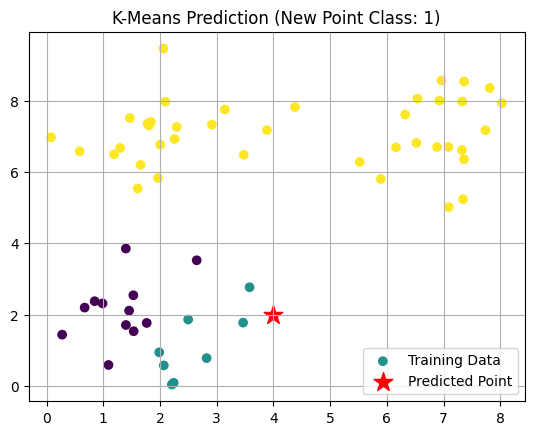

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Tính toán lại nhãn cho toàn bộ X dựa trên centroid đã train
# Sử dụng hàm distance và labeling đã định nghĩa ở cell FEyRqDDFTgtR
all_dist = distance(X, centroid)
train_labels = labeling(all_dist)

# 2. Vẽ 60 điểm dữ liệu cũ
plt.scatter(X[:, 0], X[:, 1], c=train_labels, cmap='viridis', label='Training Data')

# 3. Vẽ điểm mới new_X với màu đỏ nổi bật và kích thước lớn
plt.scatter(new_X[0], new_X[1], c='red', s=200, marker='*', label='Predicted Point')

plt.title(f"K-Means Prediction (New Point Class: {new_label[0]})")
plt.legend()
plt.grid(True)
plt.show()

## **2. Algorithms with `scikit-learn`**
- Trên đời này chẳng ai lại tự code chay cái gì cả, chúng ta sẽ dùng thư viện để làm tất cả.
- `sklearn` là thư viện cơ bản nhất về `Machine Learning`.

### **TODO 9: Cosine similarity (Medium)**
- Dùng `sklearn` để tính `cosine similarity` của 2 vector này nha.

In [ ]:
a = np.array([1,2,3,4])
b = np.array([1,2,3,5])

from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(a.reshape(1, -1), b.reshape(1, -1))
print(similarity)

[[0.99399909]]


- Thôi dễ quá. Tính `cosine similarity` giữa 2 tấm ảnh nhé.

In [ ]:
import tensorflow as tf
# Tải dataset từ Tensorflow.Keras
(x_train, y_train), (_, _) = tf.keras.datasets.mnist.load_data()
print(f"Đã tải {len(x_train)} ảnh MNIST mẫu.")
print(f"Kích thước ảnh gốc: {x_train[0].shape}") # (28, 28)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Đã tải 60000 ảnh MNIST mẫu.
Kích thước ảnh gốc: (28, 28)


- `MNist` là bộ dữ liệu kinh điển bên cạnh `iris`. Đây là bộ ảnh số được viết tay, đều là những ảnh trắng đen và cùng size `28px x 28px`.
- Hỷ đã vẽ 1 ảnh giùm rồi đó, giúp Hỷ vẽ ảnh còn lại trên cùng `subplot` nha nha.

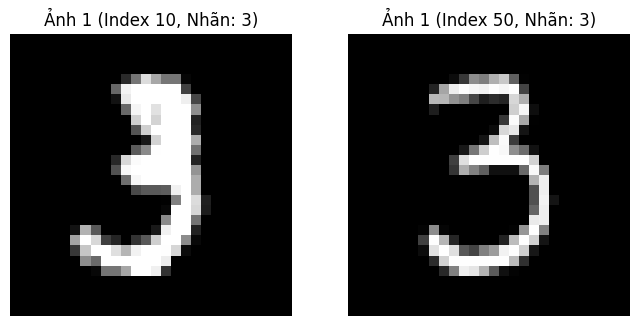

In [ ]:
# import plt
import matplotlib.pyplot as plt

# Vẽ tấm ảnh đầu tiên trong dataset

index1 = 10  # Đây là một số 7
index2 = 50  # Đây cũng là một số 7 khác
img1 = x_train[index1]
img2 = x_train[index2]

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(img1, cmap='gray')
plt.title(f"Ảnh 1 (Index {index1}, Nhãn: {y_train[index1]})")
plt.axis('off')

# Vẽ tấm ảnh còn lại nhé.
# YOUR CODE GOES HERE

plt.subplot(1, 2, 2)
plt.imshow(img2, cmap='gray')
plt.title(f"Ảnh 1 (Index {index2}, Nhãn: {y_train[index2]})")
plt.axis('off')

plt.show() # luôn để cuối

- Giờ apply `cosine similarity` giữa 2 vector ảnh đã được trải phẳng `flatten` từ 2 chiều thành 1 chiều nhé.

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# Tiền xử lý dữ liệu cho Sklearn
# 1. Chuyển về float32 và normalize pixel về khoảng [0, 1]
img1_norm = img1.astype('float32') / 255.0
img2_norm = img2.astype('float32') / 255.0

# 2. Làm phẳng (Flatten) ma trận 2D (28,28) thành vector 1D (784,)
# reshape(1, -1) chuyển nó thành dạng ma trận 1 hàng mà sklearn yêu cầu
vec1 = img1_norm.reshape(1, -1)
vec2 = img2_norm.reshape(1, -1)

# BƯỚC 5: Tính Cosine Similarity
similarity = cosine_similarity(vec1, vec2)[0][0]

print(f"------------------------------------")
print(f"Độ tương đồng Cosine: {similarity:.4f}")
print(f"------------------------------------")

------------------------------------
Độ tương đồng Cosine: 0.6901
------------------------------------


- Rõ ràng đều là hình số 7 nhưng cosine similarity khá thấp, như vậy không thể dùng `pixel-similarity` để so sánh 2 ảnh được rồi. (Dĩ nhiên là vậy).

### **TODO 10: `kMeans` (Hard)**
- Áp dụng `kMeans` cho bài toán `iris` siêu siêu siêu cơ bản nhé.

In [ ]:
# get iris dataset
from sklearn.datasets import load_iris
iris = load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

# Load the Iris dataset
iris = load_iris()

X = iris.data[:, 1:] # nó có 4 trường dữ liệu nhưng lấy 3 thôi để vẽ đồ thị
print(X.shape)

# YOUR CODE GOES HERE

(150, 3)


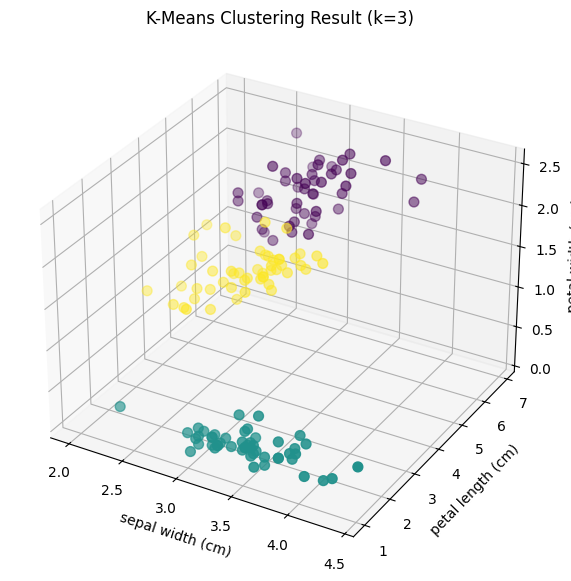

In [ ]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Set n_init explicitly to suppress warning
kmeans.fit(X)
labels = kmeans.labels_

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, cmap='viridis', s=50)

ax.set_xlabel(iris.feature_names[1])
ax.set_ylabel(iris.feature_names[2])
ax.set_zlabel(iris.feature_names[3])
ax.set_title(f"K-Means Clustering Result (k={k})")

plt.show()

- Hãy thử vẽ đồ thị 3D cho kết quả bài toán trên bằng `plt` nhé. Nãy giờ Hỷ vẽ giùm cũng hơi nhiều rồi đó.

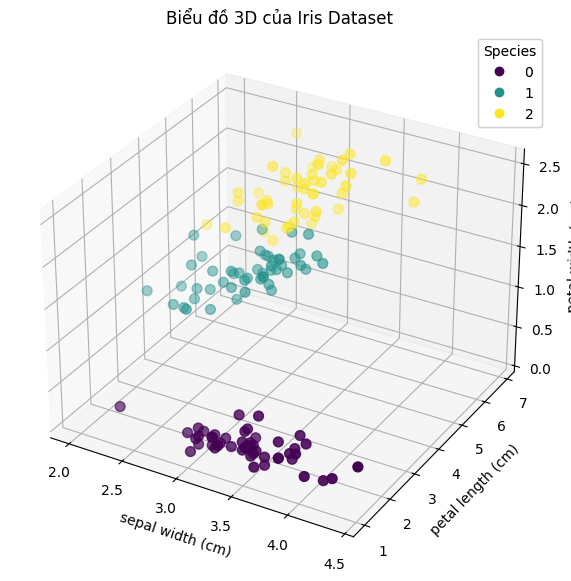

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Khởi tạo figure
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# X đã được lấy ở cell trước đó (3 đặc trưng cuối)
# iris.target là nhãn (0, 1, 2) dùng để tô màu khác nhau cho mỗi loài
scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=iris.target, cmap='viridis', s=50)

# Đặt tên cho các trục
ax.set_xlabel(iris.feature_names[1])
ax.set_ylabel(iris.feature_names[2])
ax.set_zlabel(iris.feature_names[3])
ax.set_title("Biểu đồ 3D của Iris Dataset")

# Thêm chú thích
legend1 = ax.legend(*scatter.legend_elements(), title="Species")
ax.add_artist(legend1)

plt.show()

**Silhouette Metric**

Vậy làm sao để đánh giá được mô hình `kMeans` đang chạy tốt hay không? -> `metrics` được sinh ra đời!!

- **a**: The mean distance between a sample and all other points in the same class
- **b**: The mean distance between a sample and all other points in the next nearest cluster

$$s = \frac{b-a}{max(a,b)}$$

- Giá trị silhouette nằm trong khoảng [-1,1]
- $s \approx 1$ : các điểm dữ liệu nằm đúng cluster
- $s \approx -1$ : quá ít hoặc quá nhiều cluster
- $s \approx 0$: các cluster chồng chéo lên nhau

Silhouette Score cho k=3 là: 0.5925


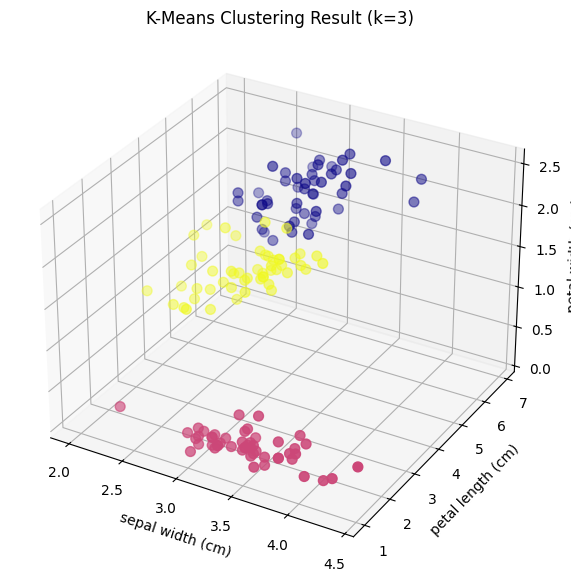

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Khởi tạo mô hình KMeans với 3 cụm
kmeans = KMeans(n_clusters=3, random_state=42)

# 2. Huấn luyện mô hình trên dữ liệu X (3 đặc trưng đã lấy)
kmeans.fit(X)

# 3. Lấy nhãn dự đoán từ mô hình
labels = kmeans.labels_

# 4. Tính toán Silhouette Score
score = silhouette_score(X, labels)
print(f"Silhouette Score cho k=3 là: {score:.4f}")

# 5. Vẽ đồ thị kết quả gom cụm (tương tự đồ thị 3D nhưng dùng nhãn của KMeans)
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, cmap='plasma', s=50)

ax.set_title("K-Means Clustering Result (k=3)")
ax.set_xlabel(iris.feature_names[1])
ax.set_ylabel(iris.feature_names[2])
ax.set_zlabel(iris.feature_names[3])

plt.show()

### **TODO 11: Gradient Descent (Medium)**

- Lớp UTS đã được nhắc qua. Hỷ không nhắc lại nha nha nha.

**Ý tưởng:** Đi ngược hướng đạo hàm/gradient vector.

$x = x - \eta \nabla_xf(x)$

<center>
<img src=https://i.imgur.com/5rIecs4.jpg>
</center>

Tìm cực tiểu của hàm số $y = f(x) = x^2 + 10sinx$ bằng thuật toán Gradient DescentDescent.

**Hướng dẫn:** Hoàn thành các hàm sau
- Hàm **`f(x)`**: nhận vào biến $x$ trả ra giá trị hàm số $f(x)$
- Hàm **`grad(x)`**: nhận vào biến $x$ và trả ra đạo hàm $f'(x)$
- Hàm **`gradient_descent`**:
  - Parameters:
    - `x0`: điểm bắt đầu tìm kiếm (random)
    - `epochs`: số lần lặp
    - `eta`: tốc độ di chuyển
  - Body:
    - Khởi tạo list kết quả `result` chứa điểm bắt đầu `x0`
    - Tạo vòng lặp `epochs` lần:
      - Lấy ra điểm cuối cùng trong list `result` gán cho biến $x_{old}$
      - Tính điểm mới theo công thức Gradient Descent: $$x_{new} = x_{old} - \eta * grad(x_{old})$$
      - Đưa $x_{new}$ vào list `result`
    - Kết thúc vòng lặp: return list chứa kết quả tìm kiếm `result`
- Gọi hàm `gradient_descent` với các tham số: `x0=0, epochs=100, eta=0.1`

In [ ]:
import numpy as np

def f(x):
  return x**2 + 10 * np.sin(x)

def grad(x):
  return 2 * x + 10 * np.cos(x)

def gradient_descent(x0, epochs, eta):
  result = [x0]
  for _ in range(epochs):
    x_old = result[-1]
    x_new = x_old - eta * grad(x_old)
    result.append(x_new)
  return result

# Gọi hàm gradient_descent với các tham số đã cho
x0 = 0
epochs = 100
eta = 0.1

result = gradient_descent(x0, epochs, eta)
print(f"Điểm cực tiểu tìm được sau {epochs} epoch là: {result[-1]:.4f}")

Điểm cực tiểu tìm được sau 100 epoch là: -1.3064


Vẽ đồ thị hàm f(x) và scatter các điểm trong list `result` trên đoạn $[-5, 6]$

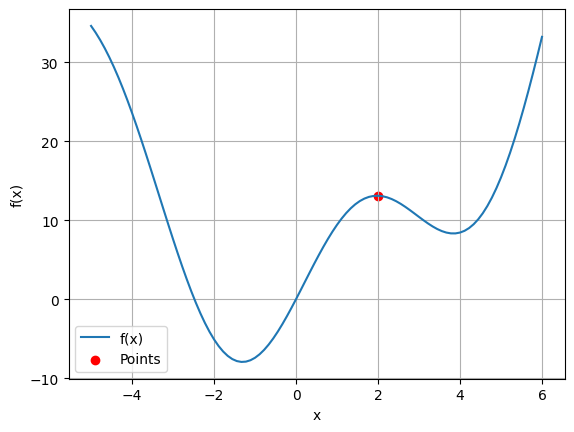

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def draw_graph(result):
    # YOUR CODE GOES HERE
    x = np.linspace(-5, 6, 100)
    y = f(x)

    plt.plot(x, y, label='f(x)')
    plt.scatter(result, f(np.array(result)), color='red', label='Points')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()
    plt.grid(True)
    plt.show()

draw_graph(result)

### **TODO 12: Gradient Descent with Momentum (Easy)**

- Công thức

$v_t = \eta\nabla_xf(x) + \gamma v_{t-1}$
$x = x - v_t = x - \eta\nabla_xf(x) - \gamma v_{t-1}$
với: $v_0 = 0$, $\gamma = 0.9$

- Tìm cực tiểu toàn cục của hàm $f(x) = x^2 + 10sinx$ bằng thuật toán **Gradient Descent with Momentum**

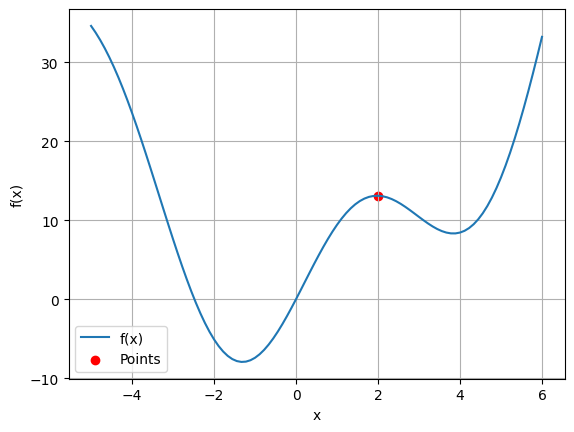

In [ ]:
def gradient_descent_with_momentum(x0, epochs, eta, gamma):
    result = [x0]
    v_old = 0
    for _ in range(epochs):
        x_old = result[-1]
        v_new = eta * grad(x_old) + gamma * v_old

        x_new = x_old - v_new
        result.append(x_new)

    return result

draw_graph(result)

# **B. PyTorch**

In [1]:
import torch
from torch import nn
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **1. Dataset & DataLoader**




Hãy cùng thực hành viết code cho Dataset và DataLoader qua ví dụ sau

Trước tiên chạy cell code bên dưới để unzip data

In [3]:
!unzip -q '/content/drive/MyDrive/s1_assignment_dataset.zip' -d '/content'

In [4]:
def device():
  return torch.device("cuda" if torch.cuda.is_available() else "cpu")
device()

device(type='cpu')

Hỷ sẽ viết class `MyDataset` đơn giản để load các tấm ảnh thuộc tập Train.

Class này gồm các attribute sau:
- `image_paths: list` chứa đường dẫn toàn bộ ảnh
- `labels: list` chứa toàn bộ nhãn theo vị trí tương ứng trong `image_paths`
- `label_info: dict` chứa thông tin nhãn, key là số nguyên còn value là string tên nhãn.

Class này có 2 hàm sau của class:
- `__init__` viết code để tạo ra toàn bộ 3 attribute trên
- `__len__` trả về số lượng dữ liệu




In [6]:
class DigitDataset(Dataset):
  def __init__(self, all_paths, all_labels):
    self.all_paths = all_paths
    self.all_labels = all_labels
    self.dataset_length = len(self.all_paths)

  def __len__(self):
    return self.dataset_length
    # return len(self.all_labels) phải tính lại ở mỗi call
    # cache lại thành biến để ra luôn kết quả

  def __getitem__(self, idx):
    image_path = self.all_paths[idx]
    # Dùng Image đọc ảnh
    # Convert L để ảnh trắng đen
    # /255 là normalize, Mr.Trang dạy rồi nha
    image = np.array(Image.open(image_path).convert('L')) / 255
    image = torch.tensor(image) # tương tự np.array
    label = self.all_labels[idx]
    return {"image_path": image_path, "image_vector": image, "label": label}

Test thử class vừa viết

In [12]:
def param(data_path):

  all_paths, all_labels = [], []

  # Này môn Programming 1 dạy rồi nhá, Hỷ khum nhắc lại nữa...
  for folder in os.listdir(data_path):
    # Dùng os để lấy path (VS Code hay Colab đều dùng được)
    folder_path = os.path.join(data_path, folder)
    image_names = os.listdir(folder_path)

    # List comprehension: viết vòng lặp để tạo list nhanh như bên dưới
    image_names = [os.path.join(folder_path, name) for name in image_names]
    image_labels = [int(folder)] * len(image_names)

    all_paths.extend(image_names) # Tương tự .append
    all_labels.extend(image_labels)

  return all_paths, all_labels # Moved return outside the loop

In [14]:
train_ds = DigitDataset(param("/content/s1_assignment_dataset/data/train")[0], param("/content/s1_assignment_dataset/data/train")[1])
test_ds = DigitDataset(param("/content/s1_assignment_dataset/data/test")[0], param("/content/s1_assignment_dataset/data/test")[1])
# train_ds[999], test_ds[999]

FileNotFoundError: [Errno 2] No such file or directory: '/content/s1_assignment_dataset/data/train'

## **2. MLP Model**

Viết mô hình `MLP` của bạn để giải quyết bài toán `Classification` trên dataset `MNIST` bên trên theo kiến trúc sau:
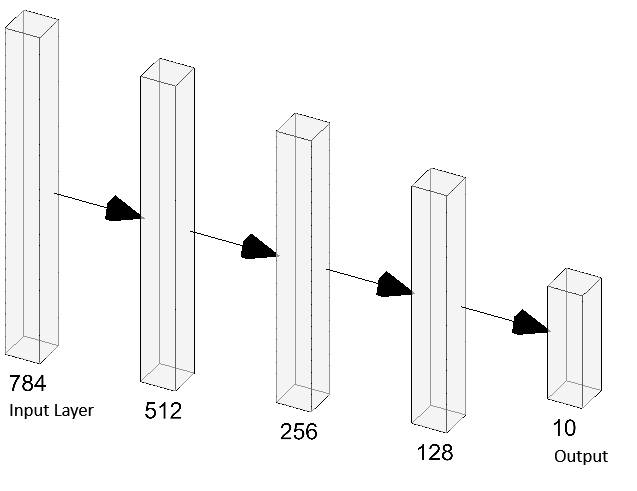

In [ ]:
class LinearRelu(nn.Module): # code riêng layer
  def __init__(self, in_features, out_features, activation):
    super().__init__()
    self.fc = nn.Linear(in_features, out_features)
    self.act = activation

  # define layer: max pooling, avg pooling, convolution, attention
  def forward(self, x):
    # return self.act(self.fc(x))
    a = self.fc(x)
    b = self.act(a)
    return b

# Khúc này đã giải thích cho V rồi, L thì chưa.
class MyMLP(nn.Module):
  def __init__(self):
    super().__init__()

    self.act = nn.ReLU()
    self.fc1 = LinearRelu(784, 512, self.act)
    self.fc2 = LinearRelu(512, 256, self.act)
    self.fc3 = LinearRelu(256, 128, self.act)
    self.predictor = nn.Linear(128, 10)

  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = self.fc1(x)
    x = self.fc2(x)
    x = self.fc3(x)
    x = self.predictor(x)
    return x

## **3. Custom Training Loop**

In [ ]:
from torch.utils.data import DataLoader
train_loader = DataLoader(train_ds, # biến dataset vừa tạo ở trên
                       batch_size = 28, # số mẫu dữ liệu trong 1 bộ nhỏ
                       shuffle = True, # re-shuffle dữ liệu sau mỗi epoch
                       num_workers = 2, # số sub-process dùng để load data
                       prefetch_factor = 2) # số lượng mini-batch được chuẩn bị sẵn trước

test_loader = DataLoader(test_ds, # biến dataset vừa tạo ở trên
                       batch_size = 28, # số mẫu dữ liệu trong 1 bộ nhỏ
                       shuffle = True, # re-shuffle dữ liệu sau mỗi epoch
                       num_workers = 2, # số sub-process dùng để load data
                       prefetch_factor = 2) # số lượng mini-batch được chuẩn bị sẵn trước

NameError: name 'train_ds' is not defined

- Khởi tạo mô hình, chuyển mô hình sang GPU
- Khởi tạo hàm loss
- Khởi tạo optimizer


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MyMLP().to(device)
total_predictions, total_labels = [], []
SGD = torch.optim.SGD(params = model.parameters(), lr = 0.01)

## **4. Evaluate**
Custom training loop để huấn luyện mô hình trên, khi evaluate trên tập Test, bạn chỉ cần tính loss.

In [ ]:
for epoch in range(5):

  # TRAINING LOOP
  model.train()
  for batch in train_loader:

    input = batch['image']
    y_true = batch['label']

    SGD.zero_grad()

    ## FORWARD PASS
    logits = model(input)
    loss = nn.MSELoss(logits, y_true) # MSE = mean squared error
                                      # MAE = mean absolute error

    # BACKWARD PASS & UPDATE WEIGHTS
    loss.backward()
    SGD.step()

  # EVALUATION LOOP
  model.eval()
  with torch.no_grad():
    for batch in test_loader:
      images = batch['image_vector']
      labels = batch['label']

      logits = model(images)
      values, classes = torch.max(logits, dim = 1)

      total_predictions.extend(classes.detach().cpu().numpy())
      total_labels.extend(labels.detach().cpu().numpy())

## **5. Inference**

Viết code để lấy ra dự đoán của mô hình trên tập Test, rồi dùng `sklearn.metrics` để in ra `classification_report`

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print(classification_report(total_labels, total_predictions))

## **TODO 13: Vietnam Dengue Fever Detection**
- Phần trên Hỷ đã demo luồng code xử lý cơ bản nhất để train 1 model.
- Tới lượt người ngồi trước màn hình code kiến trúc `Resnet50` của mình rồi nha nha.